# Foundation 3: Matplotlib — Visualisation From Zero
### Data Science for Chartered Accountants — Pre-Module

---

## What is this notebook about?

**Matplotlib** is Python's core data visualisation library. Every chart you'll ever make in Python — bar charts, pie charts, trend lines — starts here.

This notebook assumes:
- ✅ `00a_numpy_basics.ipynb` completed
- ✅ `00b_pandas_basics.ipynb` completed
- ❌ No prior Matplotlib knowledge required

## What will you learn?
1. The Figure / Axes hierarchy
2. Line plot — trends over time
3. Bar chart — comparing categories
4. Horizontal bar chart
5. Pie chart — composition
6. Scatter plot — relationships
7. Histogram — distributions
8. Customisation: titles, labels, colours, grid, legend
9. Multiple subplots
10. Saving figures
11. Bridge to accounting visuals

---

> **Matplotlib is to Python what charts are to Excel — but you have full control over every pixel.**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use inline display in Jupyter
%matplotlib inline

# Set a clean default style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

print('Matplotlib imported successfully!')
print('Version:', plt.matplotlib.__version__)

Matplotlib imported successfully!
Version: 3.10.6


---
## Section 1: The Figure / Axes Hierarchy

Understanding this will prevent 90% of your Matplotlib confusion.

```
Figure  →  the entire canvas / window
  └── Axes  →  a single plot (like a chart within the canvas)
        ├── x-axis
        ├── y-axis
        ├── title
        └── data (lines, bars, etc.)
```

One Figure can have **multiple Axes** (subplots).

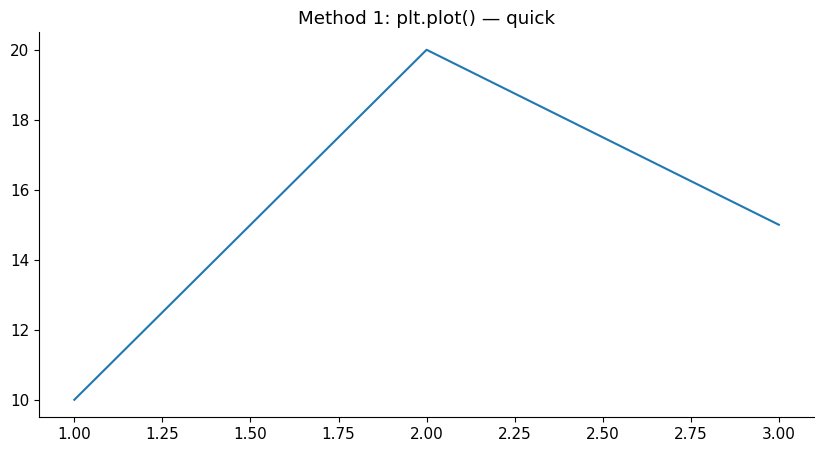

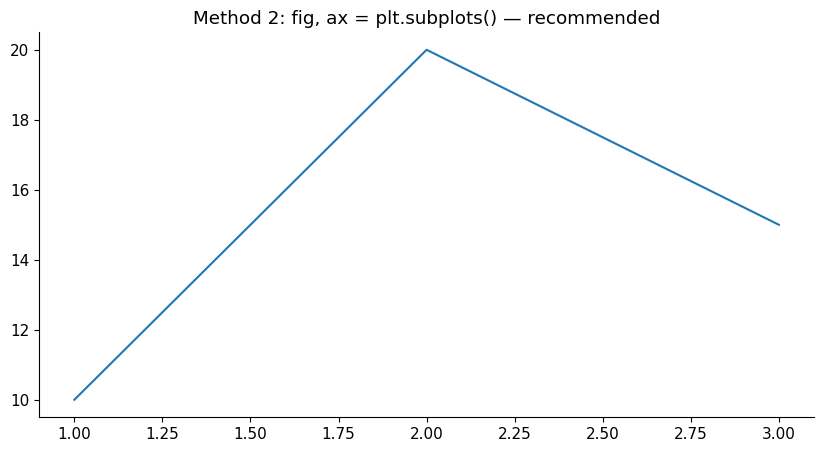

In [2]:
# Two ways to create a plot:

# ── Method 1: Quick (plt.plot) — good for single charts ──────────────────────
plt.plot([1, 2, 3], [10, 20, 15])
plt.title('Method 1: plt.plot() — quick')
plt.show()

# ── Method 2: Object-oriented (fig, ax) — recommended ────────────────────────
# More control; scales to multiple subplots
fig, ax = plt.subplots()         # create Figure + one Axes
ax.plot([1, 2, 3], [10, 20, 15])
ax.set_title('Method 2: fig, ax = plt.subplots() — recommended')
plt.show()

---
## Section 2: Line Plot — Tracking Trends

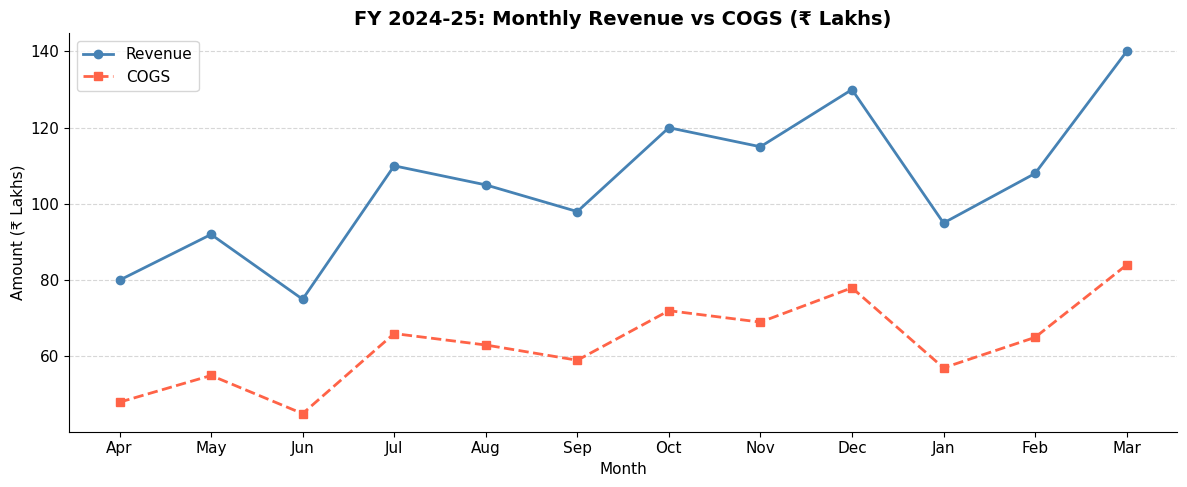

In [3]:
# Monthly revenue data
months  = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
           'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
revenue = [80, 92, 75, 110, 105, 98, 120, 115, 130, 95, 108, 140]
cogs    = [48, 55, 45, 66, 63, 59, 72, 69, 78, 57, 65, 84]

fig, ax = plt.subplots(figsize=(12, 5))

# Plot two lines
ax.plot(months, revenue, marker='o', color='steelblue',  linewidth=2, label='Revenue')
ax.plot(months, cogs,    marker='s', color='tomato',     linewidth=2, label='COGS',
        linestyle='--')

# Labels and title
ax.set_title('FY 2024-25: Monthly Revenue vs COGS (₹ Lakhs)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount (₹ Lakhs)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

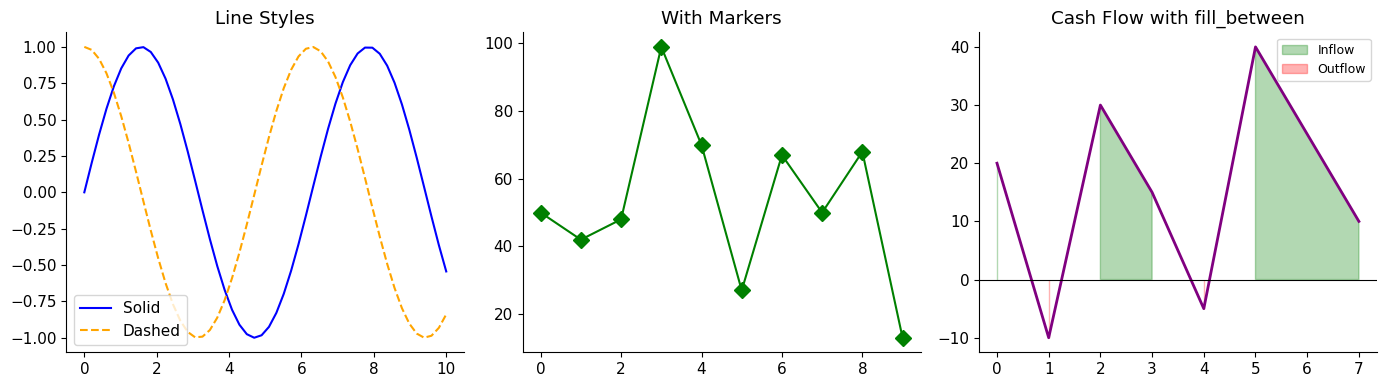

In [4]:
# ── Line customisation options ────────────────────────────────────────────────
x = np.linspace(0, 10, 50)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Different line styles
axes[0].plot(x, np.sin(x), linestyle='-',  color='blue',   label='Solid')
axes[0].plot(x, np.cos(x), linestyle='--', color='orange', label='Dashed')
axes[0].set_title('Line Styles')
axes[0].legend()

# Different markers
y = np.random.randint(10, 100, 10)
axes[1].plot(range(10), y, marker='D', color='green', markersize=8, linewidth=1.5)
axes[1].set_title('With Markers')

# Filled area under line (useful for cash flow charts)
cf = np.array([20, -10, 30, 15, -5, 40, 25, 10])
axes[2].plot(cf, color='purple', linewidth=2)
axes[2].fill_between(range(len(cf)), cf, 0,
                      where=cf >= 0, alpha=0.3, color='green', label='Inflow')
axes[2].fill_between(range(len(cf)), cf, 0,
                      where=cf < 0,  alpha=0.3, color='red',   label='Outflow')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Cash Flow with fill_between')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 3: Bar Chart — Comparing Categories

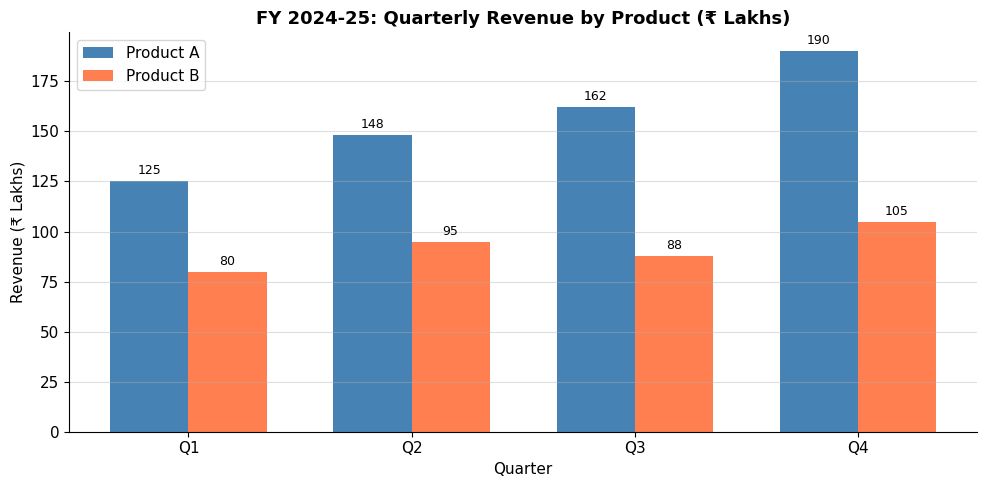

In [5]:
# Quarterly revenue by product segment
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a  = [125, 148, 162, 190]
product_b  = [80,  95,  88, 105]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_a = ax.bar(x - width/2, product_a, width, label='Product A', color='steelblue')
bars_b = ax.bar(x + width/2, product_b, width, label='Product B', color='coral')

# Add value labels on top of each bar
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('FY 2024-25: Quarterly Revenue by Product (₹ Lakhs)', fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Revenue (₹ Lakhs)')
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

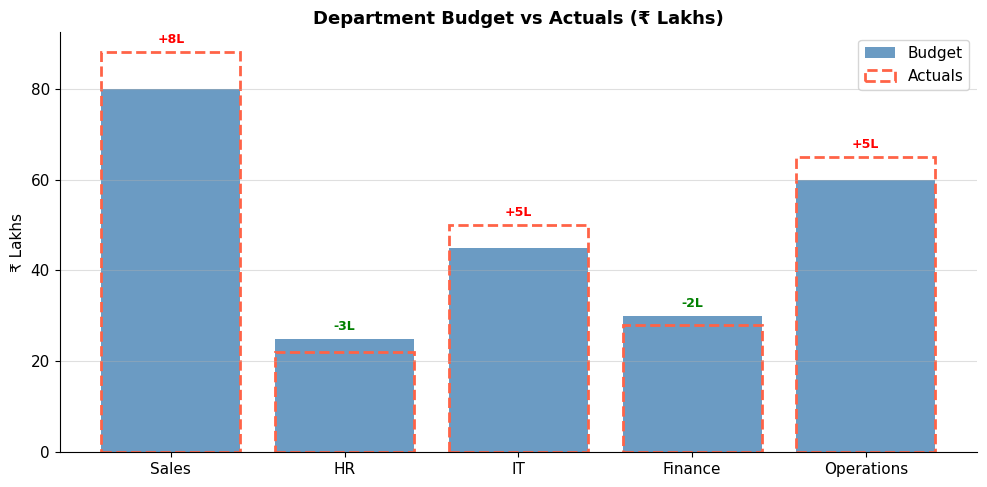

In [6]:
# ── Stacked bar chart ─────────────────────────────────────────────────────────
# Useful for: revenue breakdown by segment, budget allocation

departments = ['Sales', 'HR', 'IT', 'Finance', 'Operations']
budget      = [80, 25, 45, 30, 60]
actuals     = [88, 22, 50, 28, 65]
variance    = [a - b for a, b in zip(actuals, budget)]  # positive = over budget

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(departments))
ax.bar(x, budget,  color='steelblue', label='Budget',  alpha=0.8)
ax.bar(x, actuals, color='none',      edgecolor='tomato', linewidth=2,
       label='Actuals', linestyle='--')

# Colour variance labels: red if over-budget, green if under
for i, (d, v) in enumerate(zip(departments, variance)):
    colour = 'red' if v > 0 else 'green'
    sign   = '+' if v > 0 else ''
    ax.text(i, max(budget[i], actuals[i]) + 2, f'{sign}{v}L',
            ha='center', color=colour, fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(departments)
ax.set_title('Department Budget vs Actuals (₹ Lakhs)', fontsize=13, fontweight='bold')
ax.set_ylabel('₹ Lakhs')
ax.legend()
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Section 4: Horizontal Bar Chart

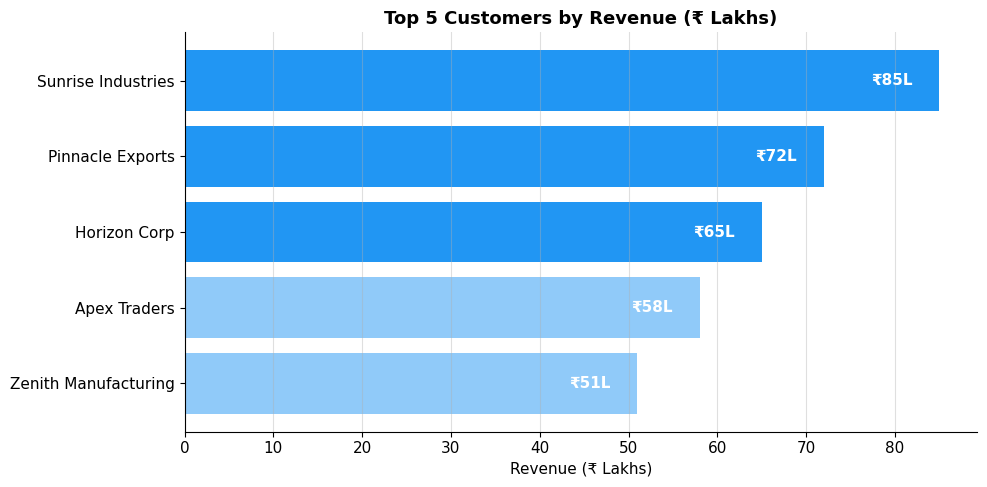

In [7]:
# Best for: ranking, long category names, top-N lists
top_customers = {
    'Sunrise Industries'   : 85_00_000,
    'Pinnacle Exports'     : 72_00_000,
    'Horizon Corp'         : 65_00_000,
    'Apex Traders'         : 58_00_000,
    'Zenith Manufacturing' : 51_00_000,
}
names  = list(top_customers.keys())
values = [v / 1_00_000 for v in top_customers.values()]  # convert to Lakhs

# Sort for better visual impact
sorted_pairs = sorted(zip(names, values), key=lambda x: x[1])
names_sorted, values_sorted = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(names_sorted, values_sorted,
               color=['#2196F3' if v > 60 else '#90CAF9' for v in values_sorted])

# Add value labels inside bars
for bar, val in zip(bars, values_sorted):
    ax.text(val - 3, bar.get_y() + bar.get_height() / 2,
            f'₹{val:.0f}L', va='center', ha='right', color='white', fontweight='bold')

ax.set_title('Top 5 Customers by Revenue (₹ Lakhs)', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (₹ Lakhs)')
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Section 5: Pie Chart — Showing Composition

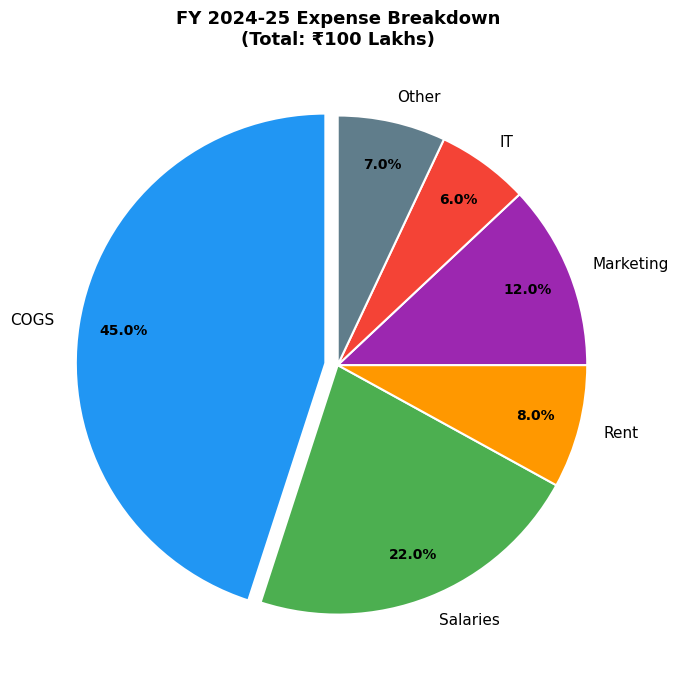

In [8]:
# Expense breakdown for the year
expense_heads = ['COGS', 'Salaries', 'Rent', 'Marketing', 'IT', 'Other']
amounts       = [45, 22, 8, 12, 6, 7]  # ₹ Lakhs

# Explode the largest slice for emphasis
explode = [0.05, 0, 0, 0, 0, 0]  # pull out COGS slightly

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#607D8B']

fig, ax = plt.subplots(figsize=(8, 7))

wedges, texts, autotexts = ax.pie(
    amounts,
    labels    = expense_heads,
    autopct   = '%1.1f%%',        # show percentage on each slice
    explode   = explode,
    colors    = colors,
    startangle = 90,              # start from top
    pctdistance = 0.82,
    wedgeprops  = dict(edgecolor='white', linewidth=1.5)
)

# Bold the auto-percentage text
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

ax.set_title('FY 2024-25 Expense Breakdown\n(Total: ₹100 Lakhs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6: Scatter Plot — Exploring Relationships

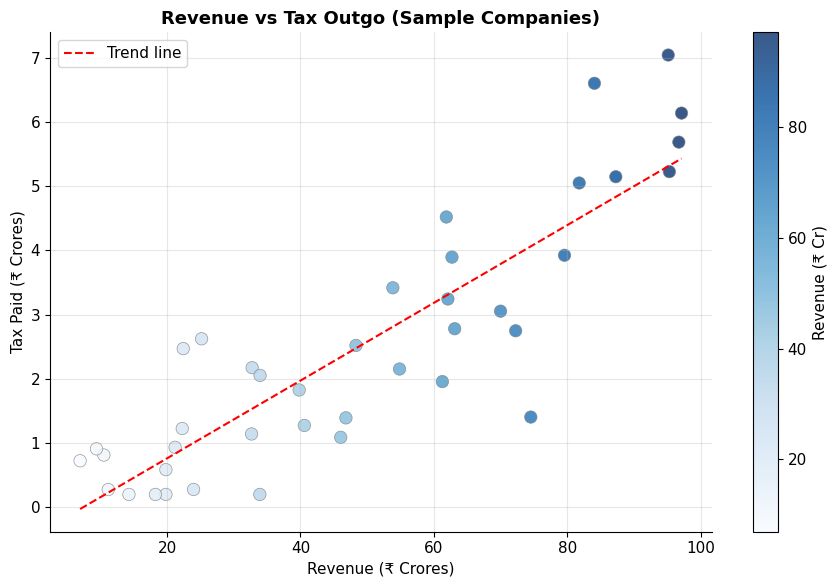

In [9]:
# Do companies with higher revenue tend to have higher tax outgo?
np.random.seed(42)
n = 40
revenue_cr = np.random.uniform(5, 100, n)           # ₹ Crores
tax_cr     = revenue_cr * np.random.uniform(0.02, 0.08, n) + np.random.randn(n) * 0.5
tax_cr     = np.clip(tax_cr, 0.2, None)

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    revenue_cr, tax_cr,
    c      = revenue_cr,  # colour by revenue (gradient)
    cmap   = 'Blues',
    s      = 80,          # marker size
    alpha  = 0.8,
    edgecolors = 'grey', linewidth=0.5
)

plt.colorbar(scatter, label='Revenue (₹ Cr)')

# Add a trend line
z  = np.polyfit(revenue_cr, tax_cr, 1)
p  = np.poly1d(z)
x_line = np.linspace(revenue_cr.min(), revenue_cr.max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend line')

ax.set_title('Revenue vs Tax Outgo (Sample Companies)', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (₹ Crores)')
ax.set_ylabel('Tax Paid (₹ Crores)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 7: Histogram — Understanding Distributions

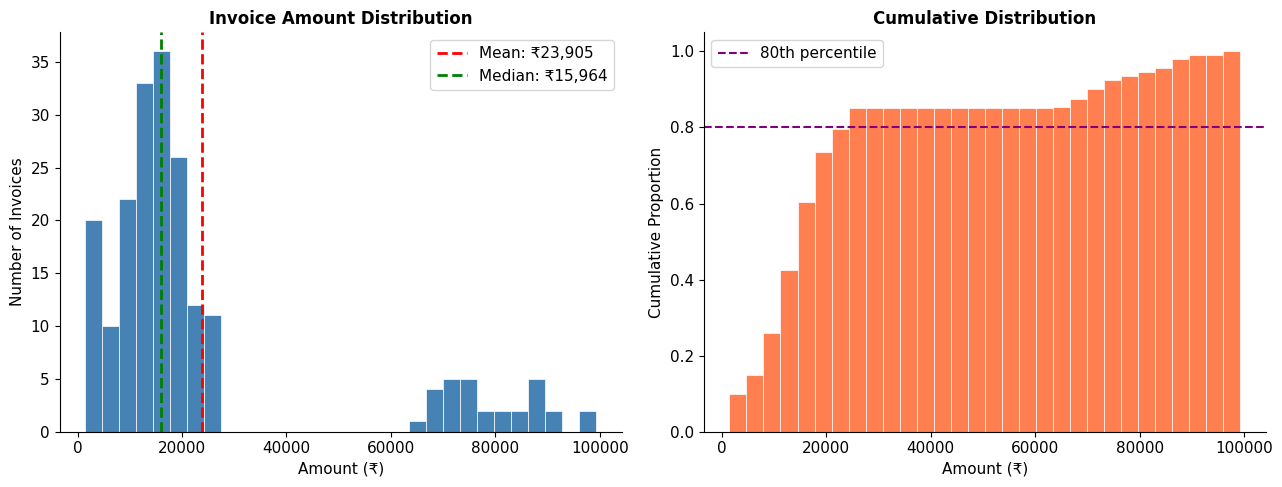

80th percentile invoice amount: ₹24,338


In [10]:
# Distribution of invoice amounts — useful for Benford's Law analysis
np.random.seed(0)
invoice_amounts = np.concatenate([
    np.random.normal(15000, 5000, 150),   # most invoices around ₹15K
    np.random.normal(80000, 10000, 30),   # some large invoices
    np.random.uniform(1000, 5000, 20),    # a few small ones
])
invoice_amounts = np.abs(invoice_amounts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Normal histogram
axes[0].hist(invoice_amounts, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(invoice_amounts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ₹{invoice_amounts.mean():,.0f}')
axes[0].axvline(np.median(invoice_amounts), color='green', linestyle='--', linewidth=2, label=f'Median: ₹{np.median(invoice_amounts):,.0f}')
axes[0].set_title('Invoice Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount (₹)')
axes[0].set_ylabel('Number of Invoices')
axes[0].legend()

# Cumulative histogram (useful for aging analysis)
axes[1].hist(invoice_amounts, bins=30, cumulative=True,
             density=True, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axhline(0.8, color='purple', linestyle='--', label='80th percentile')
axes[1].set_title('Cumulative Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount (₹)')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'80th percentile invoice amount: ₹{np.percentile(invoice_amounts, 80):,.0f}')

---
## Section 8: Customisation Toolkit

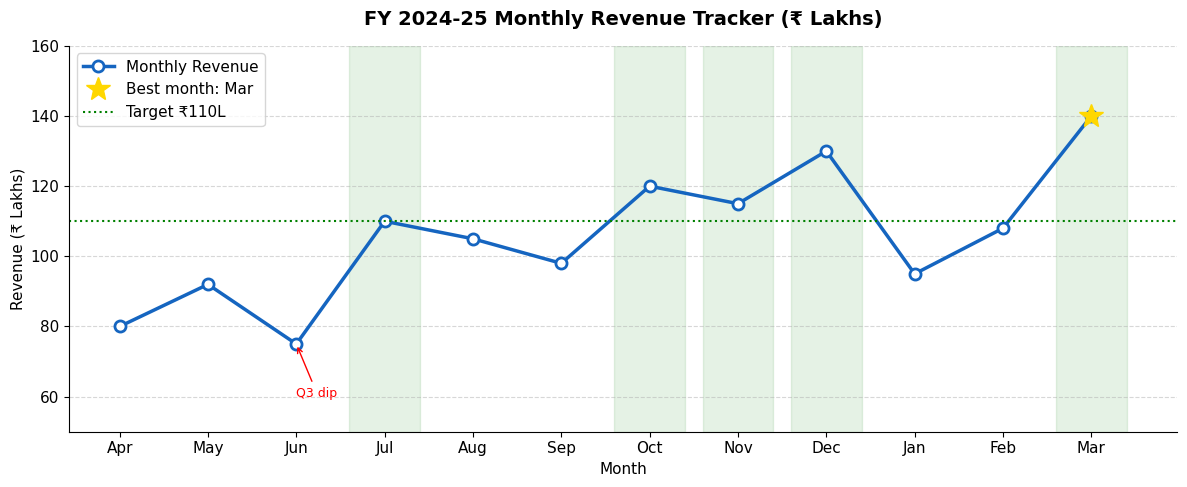

In [11]:
# Comprehensive customisation demo
months  = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
           'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
revenue = [80, 92, 75, 110, 105, 98, 120, 115, 130, 95, 108, 140]

fig, ax = plt.subplots(figsize=(12, 5))

# Main line
ax.plot(months, revenue, 'o-', color='#1565C0', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2, label='Monthly Revenue')

# Highlight best month
best_idx = np.argmax(revenue)
ax.plot(months[best_idx], revenue[best_idx], '*', color='gold',
        markersize=18, zorder=5, label=f'Best month: {months[best_idx]}')

# Horizontal target line
ax.axhline(110, color='green', linestyle=':', linewidth=1.5, label='Target ₹110L')

# Shade months above target
rev_arr = np.array(revenue)
above_target = rev_arr >= 110
for i in range(len(months)):
    if above_target[i]:
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.1, color='green')

# Annotations
ax.annotate(
    'Q3 dip',
    xy=(months.index('Jun'), 75),
    xytext=(months.index('Jun'), 60),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=9
)

# Formatting
ax.set_title('FY 2024-25 Monthly Revenue Tracker (₹ Lakhs)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (₹ Lakhs)', fontsize=11)
ax.set_ylim(50, 160)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper left', framealpha=0.8)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## Section 9: Multiple Subplots — Dashboard Layout

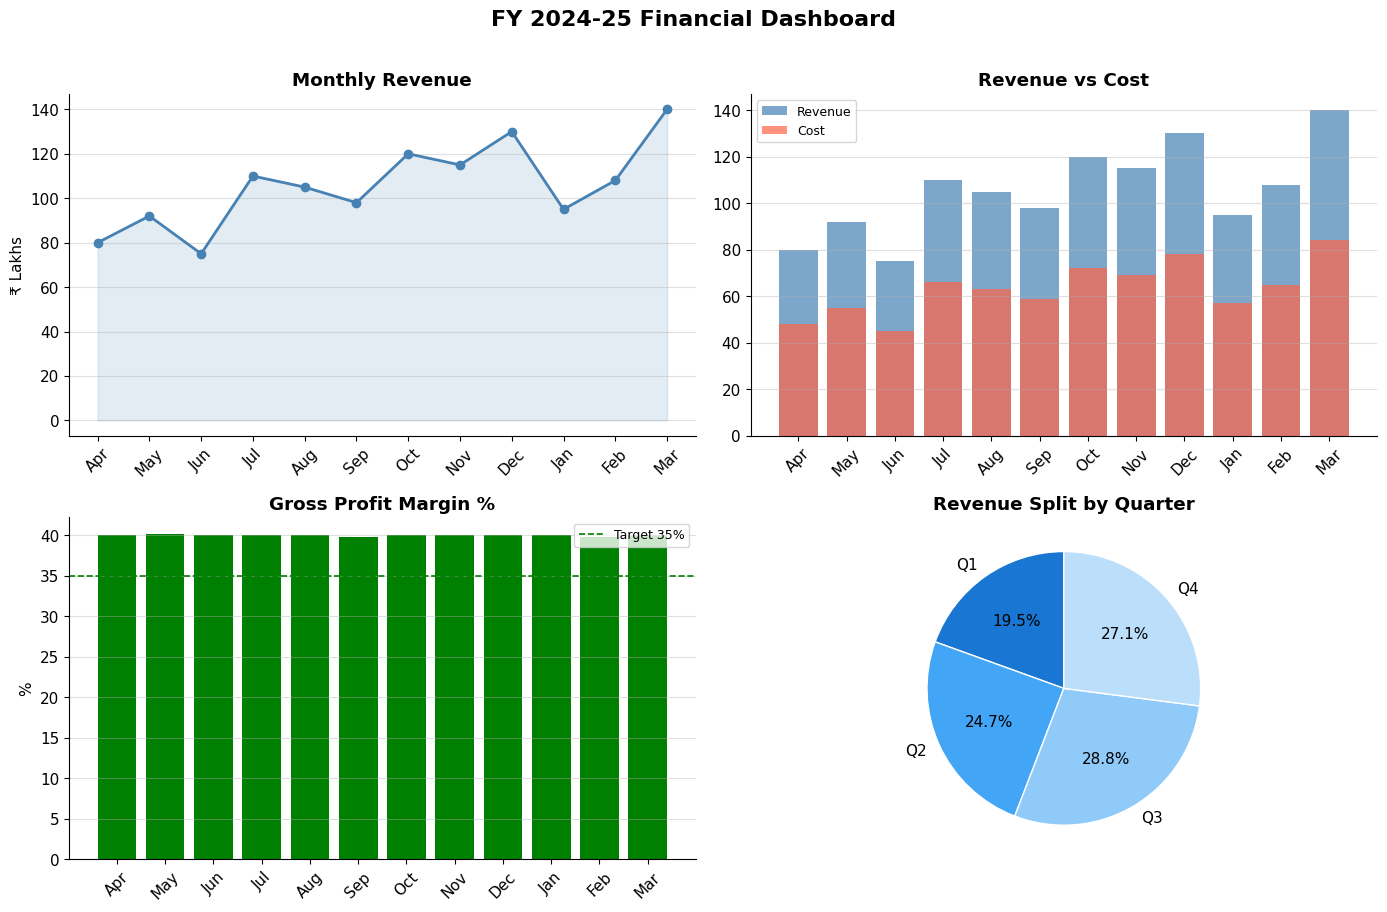

In [12]:
# Create a mini financial dashboard (2 rows × 2 columns)
months  = ['Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar']
rev     = np.array([80, 92, 75, 110, 105, 98, 120, 115, 130, 95, 108, 140])
cost    = np.array([48, 55, 45, 66,  63,  59, 72,  69,  78,  57,  65,  84])
profit  = rev - cost

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('FY 2024-25 Financial Dashboard', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1 (top-left): Revenue trend ─────────────────────────────────────────
axes[0, 0].plot(months, rev, 'o-', color='steelblue', linewidth=2)
axes[0, 0].fill_between(range(len(months)), rev, alpha=0.15, color='steelblue')
axes[0, 0].set_title('Monthly Revenue', fontweight='bold')
axes[0, 0].set_ylabel('₹ Lakhs')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.4)

# ── Plot 2 (top-right): Cost vs Revenue bars ──────────────────────────────────
x_pos = range(len(months))
axes[0, 1].bar(x_pos, rev,  color='steelblue', alpha=0.7, label='Revenue')
axes[0, 1].bar(x_pos, cost, color='tomato',    alpha=0.7, label='Cost')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(months, rotation=45)
axes[0, 1].set_title('Revenue vs Cost', fontweight='bold')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(axis='y', alpha=0.4)

# ── Plot 3 (bottom-left): Gross profit margin ─────────────────────────────────
gp_margin = profit / rev * 100
colours   = ['green' if m >= 35 else 'orange' if m >= 28 else 'red' for m in gp_margin]
axes[1, 0].bar(months, gp_margin, color=colours)
axes[1, 0].axhline(35, color='green', linestyle='--', linewidth=1.2, label='Target 35%')
axes[1, 0].set_title('Gross Profit Margin %', fontweight='bold')
axes[1, 0].set_ylabel('%')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(axis='y', alpha=0.4)

# ── Plot 4 (bottom-right): Quarterly pie ─────────────────────────────────────
qtrs       = ['Q1', 'Q2', 'Q3', 'Q4']
qtr_rev    = [rev[0:3].sum(), rev[3:6].sum(), rev[6:9].sum(), rev[9:12].sum()]
axes[1, 1].pie(qtr_rev, labels=qtrs, autopct='%1.1f%%',
               colors=['#1976D2','#42A5F5','#90CAF9','#BBDEFB'],
               startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1, 1].set_title('Revenue Split by Quarter', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Section 10: Saving Figures

Saved: sample_chart.png and sample_chart.pdf in /tmp/


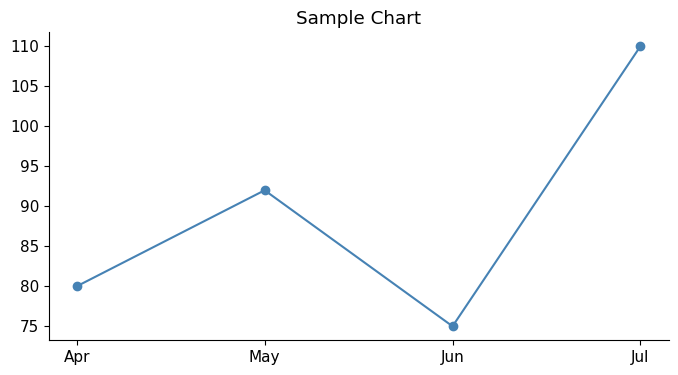

In [13]:
# Create a simple chart and save it
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(['Apr', 'May', 'Jun', 'Jul'], [80, 92, 75, 110], 'o-', color='steelblue')
ax.set_title('Sample Chart')

# Save options:
# dpi=150 → resolution (150 is good for reports, 300 for print)
# bbox_inches='tight' → prevents title/labels from being cut off

fig.savefig('/tmp/sample_chart.png', dpi=150, bbox_inches='tight')
fig.savefig('/tmp/sample_chart.pdf', bbox_inches='tight')  # vector format

print('Saved: sample_chart.png and sample_chart.pdf in /tmp/')
plt.show()

---
## Section 11: Quick Reference Summary

```python
import matplotlib.pyplot as plt

# Setup
fig, ax = plt.subplots(figsize=(10, 5))
fig, axes = plt.subplots(rows, cols, figsize=(w, h))

# Chart types
ax.plot(x, y)                    # line chart
ax.bar(x, y)                     # vertical bar
ax.barh(y, x)                    # horizontal bar
ax.scatter(x, y)                 # scatter plot
ax.hist(data, bins=20)           # histogram
ax.pie(data, labels=..., autopct='%1.1f%%')
ax.fill_between(x, y1, y2)      # shaded area

# Labels & titles
ax.set_title('Title')
ax.set_xlabel('X label')
ax.set_ylabel('Y label')
ax.legend()

# Axis limits
ax.set_xlim(0, 100)
ax.set_ylim(0, 200)
ax.set_xticks([0, 25, 50])
ax.set_xticklabels(['Low', 'Mid', 'High'])

# Reference lines
ax.axhline(y=target, color='red', linestyle='--')
ax.axvline(x=value,  color='blue')

# Style
ax.grid(alpha=0.4)
ax.annotate('Note', xy=(x,y), xytext=(x2,y2), arrowprops=dict(arrowstyle='->'))

# Display / save
plt.tight_layout()
plt.show()
fig.savefig('chart.png', dpi=150, bbox_inches='tight')
```

---
## Practice Exercises

1. Plot a line chart showing 5-year EBITDA trend for a company (use any values). Add a dashed horizontal target line at ₹50L. Highlight the year(s) above target.

2. Create a bar chart comparing Actual vs Budget for 5 expense heads. Add value labels on top.

3. Create a pie chart showing how ₹1,00,000 revenue is distributed: COGS 45%, Salaries 25%, Overheads 15%, Tax 10%, Net Profit 5%.

4. Build a 2×1 subplot dashboard: (a) monthly revenue line chart, (b) monthly profit bar chart.

5. Generate a scatter plot of accounts receivable days vs revenue for 20 companies. Add a trend line.

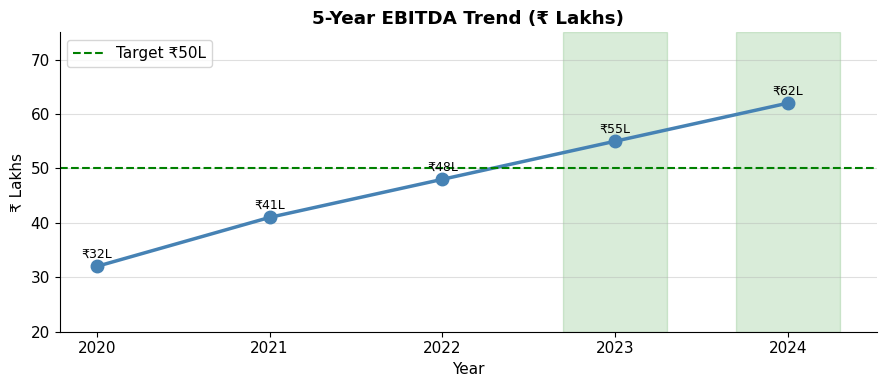

In [14]:
# ── Exercise Solutions ─────────────────────────────────────────────────────────

# Exercise 1: 5-year EBITDA
years   = [2020, 2021, 2022, 2023, 2024]
ebitda  = [32, 41, 48, 55, 62]  # ₹ Lakhs
target  = 50

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(years, ebitda, 'o-', color='steelblue', linewidth=2.5, markersize=9)
ax.axhline(target, color='green', linestyle='--', linewidth=1.5, label=f'Target ₹{target}L')

# Highlight above-target years
for yr, val in zip(years, ebitda):
    if val >= target:
        ax.axvspan(yr - 0.3, yr + 0.3, alpha=0.15, color='green')

# Value labels
for yr, val in zip(years, ebitda):
    ax.text(yr, val + 1.5, f'₹{val}L', ha='center', fontsize=9)

ax.set_title('5-Year EBITDA Trend (₹ Lakhs)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('₹ Lakhs')
ax.legend()
ax.grid(axis='y', alpha=0.4)
ax.set_ylim(20, 75)
plt.tight_layout()
plt.show()